In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

In [2]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"
DATA_BACKTESTS = PROJECT_ROOT / "data" / "backtests"

DATA_BACKTESTS.mkdir(parents=True, exist_ok=True)

X = np.load(DATA_PROCESSED / "X_windows.npy")

sample_dates = np.load(
    DATA_PROCESSED / "sample_dates.npy",
    allow_pickle=True
)

sample_tickers = np.load(
    DATA_PROCESSED / "sample_tickers.npy",
    allow_pickle=True
)

returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")
features = pd.read_parquet(DATA_PROCESSED / "features.parquet")

sup_backtest = pd.read_parquet(
    DATA_BACKTESTS / "supervised_vae_backtest_returns.parquet"
)

returns.index = pd.to_datetime(returns.index)
features.index = pd.to_datetime(features.index)
sample_dates = pd.to_datetime(sample_dates)
sup_backtest.index = pd.to_datetime(sup_backtest.index)

X.shape, sample_dates.shape, sample_tickers.shape

((70080, 60, 6), (70080,), (70080,))

In [3]:
HORIZON = 10
REBALANCE_EVERY = 10

LONG_Q = 0.8
SHORT_Q = 0.2

LATENT_DIM = 8
BETA = 1e-3
GAMMA = 0.1

N_EPOCHS = 50
PATIENCE = 10

TRANSACTION_COST = 0.001  # 10 bps

TRAIN_RATIO = 0.7
VAL_RATIO_WITHIN_TRAIN = 0.8

SEEDS = [0, 1, 2, 3, 4]

In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [5]:
def make_future_returns(returns, horizon):
    future = pd.DataFrame(
        0.0,
        index=returns.index,
        columns=returns.columns
    )

    for h in range(1, horizon + 1):
        future += returns.shift(-h)

    return future

In [6]:
future_returns = make_future_returns(returns, HORIZON)

In [7]:
y_list = []

for date, ticker in zip(sample_dates, sample_tickers):
    try:
        y_list.append(future_returns.loc[date, ticker])
    except KeyError:
        y_list.append(np.nan)

y = np.array(y_list, dtype=np.float32)

valid_mask = ~np.isnan(y)

X_valid = X[valid_mask]
y_valid = y[valid_mask]
dates_valid = sample_dates[valid_mask]
tickers_valid = sample_tickers[valid_mask]

X_valid.shape, y_valid.shape

((69780, 60, 6), (69780,))

In [8]:
all_dates = np.sort(pd.Series(dates_valid).unique())

split_date = all_dates[int(TRAIN_RATIO * len(all_dates))]

split_date

np.datetime64('2022-03-09T00:00:00.000000000')

In [9]:
train_full_mask = dates_valid < split_date
test_mask = dates_valid >= split_date

In [10]:
train_dates = np.sort(pd.Series(dates_valid[train_full_mask]).unique())

val_start = train_dates[int(VAL_RATIO_WITHIN_TRAIN * len(train_dates))]

val_start

np.datetime64('2020-11-19T00:00:00.000000000')

In [11]:
train_mask = train_full_mask & (dates_valid < val_start)
val_mask = train_full_mask & (dates_valid >= val_start)

print("Train samples:", train_mask.sum())
print("Val samples:", val_mask.sum())
print("Test samples:", test_mask.sum())

print("Train date range:", dates_valid[train_mask].min(), dates_valid[train_mask].max())
print("Val date range:", dates_valid[val_mask].min(), dates_valid[val_mask].max())
print("Test date range:", dates_valid[test_mask].min(), dates_valid[test_mask].max())

Train samples: 39060
Val samples: 9780
Test samples: 20940
Train date range: 2015-09-21 00:00:00 2020-11-18 00:00:00
Val date range: 2020-11-19 00:00:00 2022-03-08 00:00:00
Test date range: 2022-03-09 00:00:00 2024-12-16 00:00:00


In [12]:
class SupervisedCNNVAE(nn.Module):
    def __init__(self, n_features, window, latent_dim=8):
        super().__init__()

        self.n_features = n_features
        self.window = window
        self.latent_dim = latent_dim

        self.encoder_conv = nn.Sequential(
            nn.Conv1d(n_features, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, n_features, window)
            encoded = self.encoder_conv(dummy)
            self.encoded_shape = encoded.shape[1:]
            self.encoded_dim = encoded.numel()

        self.fc_mu = nn.Linear(self.encoded_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.encoded_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, self.encoded_dim)

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose1d(
                64, 32,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                32, 16,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                16, n_features,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
        )

        self.predictor = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), *self.encoded_shape)

        x_recon = self.decoder_conv(h)

        return x_recon[:, :, :self.window]

    def predict(self, z):
        return self.predictor(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)

        x_recon = self.decode(z)
        y_pred = self.predict(z)

        return x_recon, y_pred, mu, logvar

In [13]:
def supervised_vae_loss(
    x,
    x_recon,
    y,
    y_pred,
    mu,
    logvar,
    beta=1e-3,
    gamma=0.1
):
    recon_loss = nn.functional.mse_loss(
        x_recon,
        x,
        reduction="mean"
    )

    pred_loss = nn.functional.mse_loss(
        y_pred,
        y,
        reduction="mean"
    )

    kl_loss = -0.5 * torch.mean(
        torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp(),
            dim=1
        )
    )

    total_loss = recon_loss + beta * kl_loss + gamma * pred_loss

    return total_loss, recon_loss, kl_loss, pred_loss

In [14]:
def train_supervised_vae_for_seed(
    X_valid,
    y_valid,
    train_mask,
    val_mask,
    seed,
    n_epochs=50,
    patience=10
):
    set_seed(seed)

    X_cnn = np.transpose(X_valid, (0, 2, 1)).astype(np.float32)

    y_mean = y_valid[train_mask].mean()
    y_std = y_valid[train_mask].std()

    y_scaled = ((y_valid - y_mean) / (y_std + 1e-8)).astype(np.float32)

    X_train = X_cnn[train_mask]
    y_train = y_scaled[train_mask]

    X_val = X_cnn[val_mask]
    y_val = y_scaled[val_mask]

    X_train_tensor = torch.tensor(X_train)
    y_train_tensor = torch.tensor(y_train).view(-1, 1)

    X_val_tensor = torch.tensor(X_val)
    y_val_tensor = torch.tensor(y_val).view(-1, 1)

    train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=256,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(X_val_tensor, y_val_tensor),
        batch_size=256,
        shuffle=False
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    _, n_features, window = X_cnn.shape

    model = SupervisedCNNVAE(
        n_features=n_features,
        window=window,
        latent_dim=LATENT_DIM
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    best_val_corr = -np.inf
    best_state = None
    best_epoch = None
    epochs_without_improvement = 0

    history = {
        "val_corr": [],
    }

    for epoch in range(n_epochs):
        model.train()

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            x_recon, y_pred, mu, logvar = model(xb)

            loss, recon_loss, kl_loss, pred_loss = supervised_vae_loss(
                xb,
                x_recon,
                yb,
                y_pred,
                mu,
                logvar,
                beta=BETA,
                gamma=GAMMA
            )

            loss.backward()
            optimizer.step()

        model.eval()

        y_true_all = []
        y_pred_all = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                x_recon, y_pred, mu, logvar = model(xb)

                y_true_all.append(yb.cpu().numpy())
                y_pred_all.append(y_pred.cpu().numpy())

        y_true_all = np.concatenate(y_true_all).ravel()
        y_pred_all = np.concatenate(y_pred_all).ravel()

        val_corr = np.corrcoef(y_true_all, y_pred_all)[0, 1]
        history["val_corr"].append(val_corr)

        if val_corr > best_val_corr:
            best_val_corr = val_corr
            best_epoch = epoch
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch % 5 == 0:
            print(
                f"Seed {seed} | Epoch {epoch:03d} | "
                f"val corr: {val_corr:.4f} | "
                f"best: {best_val_corr:.4f}"
            )

        if epochs_without_improvement >= patience:
            print(
                f"Seed {seed} early stopping at epoch {epoch}, "
                f"best epoch {best_epoch}, best corr {best_val_corr:.4f}"
            )
            break

    model.load_state_dict(best_state)

    return model, y_mean, y_std, best_val_corr, best_epoch, history

In [15]:
def predict_supervised_vae_scores(model, X_input, y_mean, y_std):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_cnn = np.transpose(X_input, (0, 2, 1)).astype(np.float32)
    X_tensor = torch.tensor(X_cnn)

    loader = DataLoader(
        TensorDataset(X_tensor),
        batch_size=512,
        shuffle=False
    )

    preds = []

    model.eval()

    with torch.no_grad():
        for batch in loader:
            xb = batch[0].to(device)

            mu, logvar = model.encode(xb)
            pred_scaled = model.predict(mu)

            preds.append(pred_scaled.cpu().numpy())

    preds = np.concatenate(preds).ravel()

    return preds * y_std + y_mean

In [16]:
all_seed_scores = []
seed_diagnostics = []

for seed in SEEDS:
    print("\n" + "=" * 60)
    print(f"Training seed {seed}")
    print("=" * 60)

    model, y_mean, y_std, best_val_corr, best_epoch, history = train_supervised_vae_for_seed(
        X_valid=X_valid,
        y_valid=y_valid,
        train_mask=train_mask,
        val_mask=val_mask,
        seed=seed,
        n_epochs=N_EPOCHS,
        patience=PATIENCE
    )

    test_scores = predict_supervised_vae_scores(
        model=model,
        X_input=X_valid[test_mask],
        y_mean=y_mean,
        y_std=y_std
    )

    score_long = pd.DataFrame({
        "date": dates_valid[test_mask],
        "ticker": tickers_valid[test_mask],
        f"score_seed_{seed}": test_scores,
    })

    all_seed_scores.append(score_long)

    seed_diagnostics.append({
        "seed": seed,
        "best_val_corr": best_val_corr,
        "best_epoch": best_epoch,
    })


Training seed 0
Seed 0 | Epoch 000 | val corr: 0.0038 | best: 0.0038
Seed 0 | Epoch 005 | val corr: 0.0243 | best: 0.0243
Seed 0 | Epoch 010 | val corr: 0.0116 | best: 0.0243
Seed 0 | Epoch 015 | val corr: -0.0239 | best: 0.0243
Seed 0 early stopping at epoch 15, best epoch 5, best corr 0.0243

Training seed 1
Seed 1 | Epoch 000 | val corr: 0.0393 | best: 0.0393
Seed 1 | Epoch 005 | val corr: 0.0346 | best: 0.0393
Seed 1 | Epoch 010 | val corr: 0.0243 | best: 0.0424
Seed 1 | Epoch 015 | val corr: 0.0331 | best: 0.0456
Seed 1 | Epoch 020 | val corr: 0.0279 | best: 0.0456
Seed 1 early stopping at epoch 23, best epoch 13, best corr 0.0456

Training seed 2
Seed 2 | Epoch 000 | val corr: 0.0077 | best: 0.0077
Seed 2 | Epoch 005 | val corr: -0.0126 | best: 0.0285
Seed 2 | Epoch 010 | val corr: 0.0031 | best: 0.0285
Seed 2 early stopping at epoch 12, best epoch 2, best corr 0.0285

Training seed 3
Seed 3 | Epoch 000 | val corr: 0.0188 | best: 0.0188
Seed 3 | Epoch 005 | val corr: 0.0138 | be

In [17]:
seed_diag_df = pd.DataFrame(seed_diagnostics)

seed_diag_df

,seed,best_val_corr,best_epoch
0,0,0.024257,5
1,1,0.045606,13
2,2,0.028474,2
3,3,0.026447,2
4,4,0.024860,5


In [18]:
ensemble_score_long = all_seed_scores[0]

for df in all_seed_scores[1:]:
    ensemble_score_long = ensemble_score_long.merge(
        df,
        on=["date", "ticker"],
        how="inner"
    )

score_cols = [
    c for c in ensemble_score_long.columns
    if c.startswith("score_seed_")
]

ensemble_score_long["ensemble_score"] = (
    ensemble_score_long[score_cols].mean(axis=1)
)

ensemble_score_long.head()

,date,ticker,score_seed_0,score_seed_1,score_seed_2,score_seed_3,score_seed_4,ensemble_score
0,2022-03-09,AAPL,0.004346,0.015566,0.011763,0.010415,0.013804,0.011179
1,2022-03-10,AAPL,0.004557,0.011379,0.011715,0.010814,0.015153,0.010724
2,2022-03-11,AAPL,0.004501,0.011946,0.012722,0.011105,0.017535,0.011562
3,2022-03-14,AAPL,0.004037,0.006247,0.014586,0.012064,0.017987,0.010984
4,2022-03-15,AAPL,0.004287,0.004421,0.014298,0.012800,0.018937,0.010948


In [19]:
ensemble_score_long[score_cols + ["ensemble_score"]].describe()

,score_seed_0,score_seed_1,score_seed_2,score_seed_3,score_seed_4,ensemble_score
count,20940.000000,20940.000000,20940.000000,20940.000000,20940.000000,20940.000000
mean,0.012808,0.012697,0.013070,0.010582,0.012635,0.012358
std,0.016333,0.023845,0.012888,0.011238,0.016775,0.014340
min,-0.064262,-0.222259,-0.042033,-0.038887,-0.094564,-0.082265
25%,0.003372,0.001323,0.004841,0.003773,0.003954,0.004443
50%,0.008689,0.009651,0.009897,0.007905,0.009505,0.008864
75%,0.018937,0.020602,0.018055,0.014811,0.017535,0.017061
max,0.146481,0.211036,0.095833,0.078091,0.128550,0.118725


In [20]:
def performance_stats(r):
    r = r.dropna()

    total_return = (1 + r).prod() - 1
    ann_return = (1 + total_return) ** (252 / len(r)) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    equity = (1 + r).cumprod()
    drawdown = equity / equity.cummax() - 1

    return pd.Series({
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": drawdown.min(),
    })

In [21]:
def build_rebalanced_positions_from_scores(
    score_df,
    rebalance_every=10,
    long_q=0.8,
    short_q=0.2
):
    positions = pd.DataFrame(
        0.0,
        index=score_df.index,
        columns=score_df.columns
    )

    current_position = pd.Series(0.0, index=score_df.columns)

    for i, date in enumerate(score_df.index):
        if i % rebalance_every == 0:
            scores = score_df.loc[date].dropna()

            long_threshold = scores.quantile(long_q)
            short_threshold = scores.quantile(short_q)

            new_position = pd.Series(0.0, index=score_df.columns)
            new_position.loc[scores[scores >= long_threshold].index] = 1.0
            new_position.loc[scores[scores <= short_threshold].index] = -1.0

            current_position = new_position

        positions.loc[date] = current_position

    return positions

In [22]:
def portfolio_returns_from_positions(
    positions,
    returns,
    transaction_cost=0.0
):
    next_returns = returns.shift(-1)

    common_index = positions.index.intersection(next_returns.index)
    common_cols = positions.columns.intersection(next_returns.columns)

    pos = positions.loc[common_index, common_cols]
    ret = next_returns.loc[common_index, common_cols]

    gross = (pos * ret).mean(axis=1)

    turnover = pos.diff().abs().mean(axis=1).fillna(0.0)
    net = gross - transaction_cost * turnover

    return net, turnover

In [23]:
ensemble_score_wide = ensemble_score_long.pivot(
    index="date",
    columns="ticker",
    values="ensemble_score"
).sort_index()

ensemble_score_wide.head()

ticker,AAPL,ABBV,ADBE,AMD,AMZN,AVGO,BAC,COST,CRM,CSCO,...,NFLX,NVDA,ORCL,PEP,PG,TSLA,UNH,V,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
2022-03-09,0.011179,0.007065,0.037186,0.041213,0.024224,0.018796,0.008248,0.007096,0.037823,0.004029,...,0.027841,0.049439,0.017785,0.007463,0.004311,0.050573,0.007941,0.009970,0.008254,-0.009944
2022-03-10,0.010724,0.007206,0.036673,0.041694,0.026668,0.018978,0.009312,0.007504,0.038205,0.004925,...,0.029823,0.048270,0.016946,0.007560,0.004216,0.046194,0.008511,0.012212,0.008221,-0.009260
2022-03-11,0.011562,0.007819,0.036493,0.037285,0.027906,0.020903,0.009235,0.008851,0.039685,0.006624,...,0.031866,0.046084,0.016805,0.007603,0.004446,0.041214,0.009479,0.012889,0.007964,-0.007597
2022-03-14,0.010984,0.007834,0.037340,0.039598,0.030278,0.021185,0.010857,0.009813,0.040937,0.007905,...,0.034560,0.048965,0.016469,0.007419,0.003329,0.039471,0.009566,0.014628,0.007425,-0.008268
2022-03-15,0.010948,0.007656,0.037606,0.040273,0.032280,0.021555,0.011573,0.010260,0.043044,0.009127,...,0.039248,0.049565,0.015709,0.007187,0.003005,0.038140,0.009775,0.016360,0.007050,-0.007399


In [24]:
ensemble_positions = build_rebalanced_positions_from_scores(
    ensemble_score_wide,
    rebalance_every=REBALANCE_EVERY,
    long_q=LONG_Q,
    short_q=SHORT_Q
)

ensemble_returns, ensemble_turnover = portfolio_returns_from_positions(
    ensemble_positions,
    returns,
    transaction_cost=TRANSACTION_COST
)

ensemble_returns.name = "supervised_vae_ensemble"

In [25]:
performance_stats(ensemble_returns)

total_return    0.149388
ann_return      0.051551
ann_vol         0.055198
sharpe          0.933937
max_drawdown   -0.089504
dtype: float64

In [26]:
single_seed_returns = {}
single_seed_turnovers = {}

for seed in SEEDS:
    score_col = f"score_seed_{seed}"

    score_wide = ensemble_score_long.pivot(
        index="date",
        columns="ticker",
        values=score_col
    ).sort_index()

    positions = build_rebalanced_positions_from_scores(
        score_wide,
        rebalance_every=REBALANCE_EVERY,
        long_q=LONG_Q,
        short_q=SHORT_Q
    )

    r, t = portfolio_returns_from_positions(
        positions,
        returns,
        transaction_cost=TRANSACTION_COST
    )

    single_seed_returns[f"seed_{seed}"] = r
    single_seed_turnovers[f"seed_{seed}"] = t

In [27]:
single_seed_returns_df = pd.concat(single_seed_returns, axis=1)

single_seed_stats = single_seed_returns_df.apply(performance_stats).T

single_seed_stats

,total_return,ann_return,ann_vol,sharpe,max_drawdown
seed_0,0.108137,0.037767,0.055028,0.686314,-0.074780
seed_1,0.047570,0.016920,0.048303,0.350287,-0.059927
seed_2,0.113604,0.039612,0.059292,0.668084,-0.073405
seed_3,0.110050,0.038413,0.057255,0.670916,-0.064634
seed_4,0.100521,0.035186,0.055362,0.635553,-0.069425


In [28]:
comparison = pd.concat(
    [
        sup_backtest["raw_feature_ridge"],
        sup_backtest["supervised_vae_direct"],
        ensemble_returns,
        single_seed_returns_df
    ],
    axis=1
).dropna()

stats = comparison.apply(performance_stats).T

stats.sort_values("sharpe", ascending=False)

,total_return,ann_return,ann_vol,sharpe,max_drawdown
supervised_vae_direct,0.249903,0.083865,0.053503,1.567479,-0.059883
raw_feature_ridge,0.190417,0.064951,0.068585,0.947015,-0.106181
supervised_vae_ensemble,0.149388,0.051551,0.055198,0.933937,-0.089504
seed_0,0.108137,0.037767,0.055028,0.686314,-0.074780
seed_3,0.110050,0.038413,0.057255,0.670916,-0.064634
seed_2,0.113604,0.039612,0.059292,0.668084,-0.073405
seed_4,0.100521,0.035186,0.055362,0.635553,-0.069425
seed_1,0.047570,0.016920,0.048303,0.350287,-0.059927


In [29]:
turnover_stats = {
    "supervised_vae_ensemble": ensemble_turnover.mean(),
}

for seed in SEEDS:
    turnover_stats[f"seed_{seed}"] = single_seed_turnovers[f"seed_{seed}"].mean()

turnover_stats = pd.Series(turnover_stats)

turnover_stats

supervised_vae_ensemble    0.033524
seed_0                     0.036390
seed_1                     0.040879
seed_2                     0.029226
seed_3                     0.029608
seed_4                     0.036008
dtype: float64

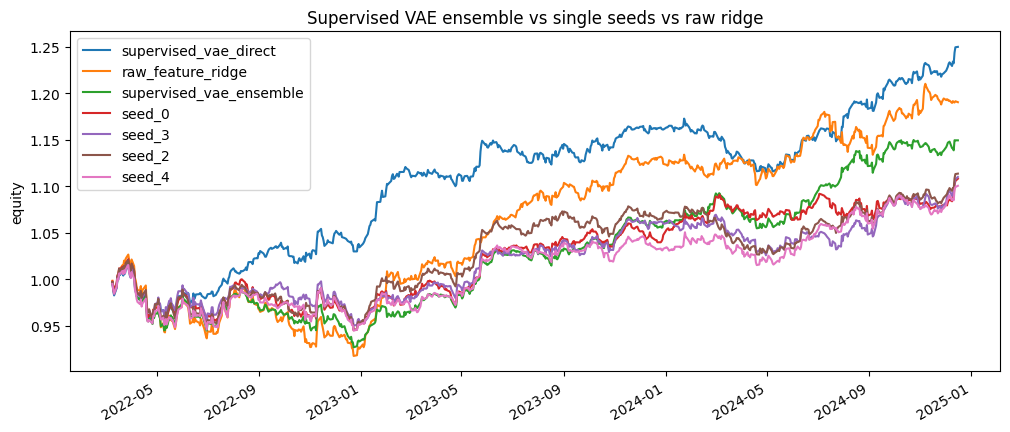

In [30]:
top_models = stats.sort_values("sharpe", ascending=False).head(7).index

equity = (1 + comparison[top_models]).cumprod()

equity.plot(
    figsize=(12, 5),
    title="Supervised VAE ensemble vs single seeds vs raw ridge"
)

plt.ylabel("equity")
plt.show()

In [31]:
seed_corr_matrix = ensemble_score_long[score_cols].corr()

seed_corr_matrix

,score_seed_0,score_seed_1,score_seed_2,score_seed_3,score_seed_4
score_seed_0,1.000000,0.687276,0.805269,0.733884,0.842127
score_seed_1,0.687276,1.000000,0.632419,0.502465,0.727249
score_seed_2,0.805269,0.632419,1.000000,0.823993,0.837941
score_seed_3,0.733884,0.502465,0.823993,1.000000,0.758163
score_seed_4,0.842127,0.727249,0.837941,0.758163,1.000000


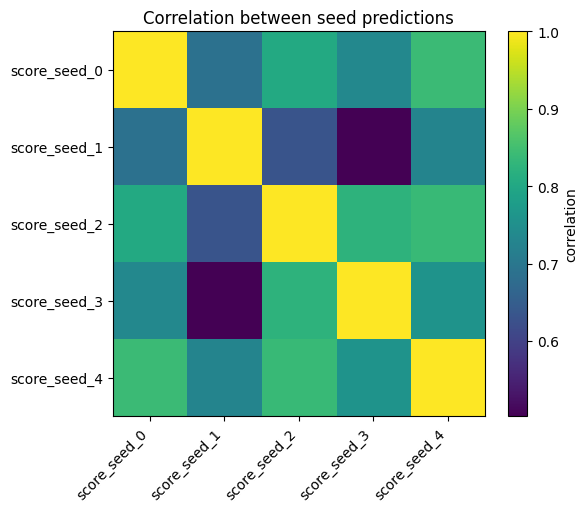

In [32]:
plt.figure(figsize=(6, 5))

plt.imshow(seed_corr_matrix, aspect="auto")
plt.colorbar(label="correlation")

plt.xticks(range(len(score_cols)), score_cols, rotation=45, ha="right")
plt.yticks(range(len(score_cols)), score_cols)

plt.title("Correlation between seed predictions")
plt.show()

In [33]:
comparison.to_parquet(
    DATA_BACKTESTS / "supervised_vae_ensemble_comparison_returns.parquet"
)

stats.to_csv(
    DATA_BACKTESTS / "supervised_vae_ensemble_comparison_stats.csv"
)

seed_diag_df.to_csv(
    DATA_BACKTESTS / "supervised_vae_ensemble_seed_diagnostics.csv",
    index=False
)

ensemble_score_long.to_parquet(
    DATA_BACKTESTS / "supervised_vae_ensemble_scores.parquet"
)

In [34]:
seed_diag_df

,seed,best_val_corr,best_epoch
0,0,0.024257,5
1,1,0.045606,13
2,2,0.028474,2
3,3,0.026447,2
4,4,0.024860,5


In [35]:
stats.sort_values("sharpe", ascending=False)

,total_return,ann_return,ann_vol,sharpe,max_drawdown
supervised_vae_direct,0.249903,0.083865,0.053503,1.567479,-0.059883
raw_feature_ridge,0.190417,0.064951,0.068585,0.947015,-0.106181
supervised_vae_ensemble,0.149388,0.051551,0.055198,0.933937,-0.089504
seed_0,0.108137,0.037767,0.055028,0.686314,-0.074780
seed_3,0.110050,0.038413,0.057255,0.670916,-0.064634
seed_2,0.113604,0.039612,0.059292,0.668084,-0.073405
seed_4,0.100521,0.035186,0.055362,0.635553,-0.069425
seed_1,0.047570,0.016920,0.048303,0.350287,-0.059927


In [36]:
turnover_stats

supervised_vae_ensemble    0.033524
seed_0                     0.036390
seed_1                     0.040879
seed_2                     0.029226
seed_3                     0.029608
seed_4                     0.036008
dtype: float64